# Отчет по исследованию данных авиаперелетов (NY Flights)

Проанализировать данные о перелетах из аэропортов Нью-Йорка в 2013 году, выявить закономерности, проверить статистические гипотезы и построить прогнозные модели.

Набор данных `flights_NY.csv` содержит информацию о задержках, времени полета, расстоянии, авиакомпаниях, типах самолетов и т.д.

1. Очистка данных.  
2. Оценка вероятности задержки для авиакомпаний с большим парком.  
3. Оценка среднего времени полета (доверительный интервал).  
4. Сравнение скоростей авиакомпаний WN и UA.  
5. Регрессионный анализ зависимости расстояния от скорости.  
6. Кластеризация самолетов по числу рейсов и средней скорости.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
#Добавил эти библиотеки, чтобы файл открывался
import requests
from io import StringIO

## Предобработка данных
Удаляем записи с пропущенными `tailnum` и `air_time`, так как они критичны для анализа.

In [34]:
#Пришлось исправить код открытия файла
url = 'https://raw.githubusercontent.com/gordeyAI/-/main/flights_NY.csv'
response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
response.raise_for_status()  # проверит, есть ли ошибка
df = pd.read_csv(StringIO(response.text))
df_clean = df.dropna(subset=['tailnum', 'air_time'])

**Удалено строк**: 336776 - 327346 = 9430 Потери минимальные, продолжаем.

## Задача 1. Вероятность задержки для крупных авиакомпаний
**Исследуем:**  
Какова вероятность задержки вылета (`dep_delay > 0`) для авиакомпаний, у которых в парке более 200 самолетов?  
**Метод:**  
- Отбор авиакомпаний с >200 уникальных `tailnum`.  
- Для каждой такой компании: `P(задержка) = число задержанных рейсов / общее число рейсов`.

In [40]:
ny_flights = df_clean[df_clean['origin'].isin(['EWR', 'LGA', 'JFK'])]
planes = df_clean.groupby('carrier')['tailnum'].nunique()
planes200 = planes[planes > 200].sort_values(ascending=False)
car_over_200 = ny_flights[ny_flights['carrier'].isin(planes200.index)]
car200_delay = car_over_200.groupby('carrier')['dep_delay'].count()
car200_delayed = car_over_200[car_over_200['dep_delay'] > 0].groupby('carrier')['dep_delay'].count()
probability = round(car200_delayed / car200_delay, 4)
print(probability)

carrier
9E    0.4036
AA    0.3163
DL    0.3186
EV    0.4496
MQ    0.3182
UA    0.4694
US    0.2401
WN    0.5426
Name: dep_delay, dtype: float64


**Авиакомпании с 200 и более самолетами**
*9E (0.4036)*
*AA (0.3163)*
*DL (0.3186)*
*EV (0.4496)*
*MQ (0.3182)*
*UA (0.4694)*
*US (0.2401)*
*WN (0.5426)*

**расчеты проведены, можно приступать к построению графика**

По оси X — авиакомпании с большим парком, по оси Y — доля задержанных рейсов. График наглядно показывает лидеров по надежности.

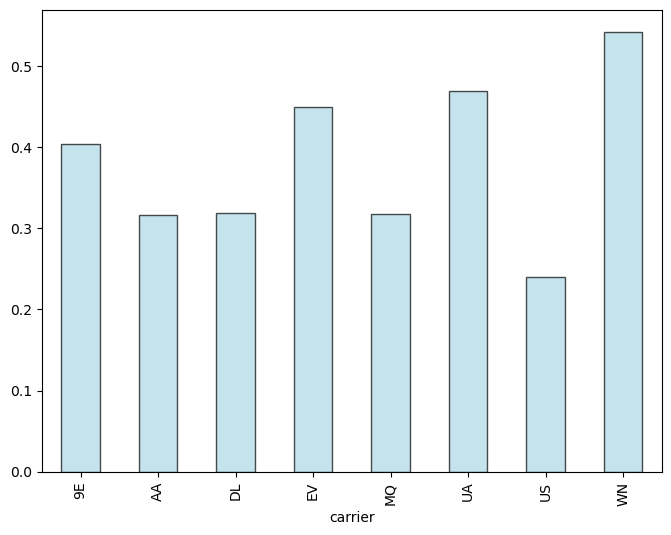

In [30]:
plt.figure(figsize=(8, 6))
ax = probability.plot(kind='bar', alpha=0.7, color='lightblue', edgecolor='black')

Наибольшая вероятность задержки у авиакомпании `WN` (0.54), наименьшая — у `US` (0.24). Это может быть связано с различиями в операционной эффективности.

## Задача 2. Оценка среднего времени полета (доверительный интервал)
**Исследуем:**  
Среднее время полета для каждого самолета (группировка по `tailnum`) и 95% доверительный интервал для генерального среднего.  
**Метод:**  
Нормальная аппроксимация (среднее +- 1.96 стандартных отклонения)

In [50]:
mean_time = df_clean.groupby('tailnum')['air_time'].mean()
mu = mean_time.mean()
sigma = mean_time.std()
print(f"mu = {mu:.1f}, sigma = {sigma:.1f}")

mu = 157.5, sigma = 75.8


**Интерпретация:**  
95% интервал: [8.9, 306.1] минут

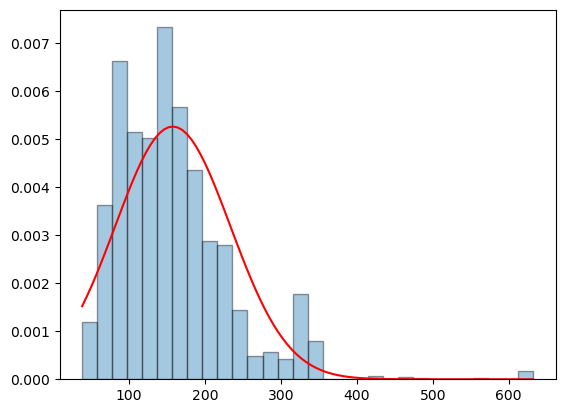

In [48]:
plt.hist(mean_time, bins=30, density=True, alpha=0.4, edgecolor='black')
x = np.linspace(mean_time.min(), mean_time.max(), 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-')
plt.show()

**График:**  
Гистограмма распределения средних времен полета с наложенной нормальной кривой. Асимметрия вправо — много коротких рейсов, небольшое количество очень длинных.

## Задача 3. Сравнение скоростей WN и UA
**Исследуем:**  
Есть ли статистически значимое различие в средней скорости полета между авиакомпаниями WN и UA.  
**Метод:**  
t-тест для 2 групп самолетов.

In [51]:
df_wnua = df_clean[df_clean['carrier'].isin(['WN','UA'])].copy()
df_wnua['speed'] = round((df_wnua['distance']/df_wnua['air_time'])*60,4)

In [13]:
df_wnua_aver = df_wnua.groupby(['carrier', 'tailnum'])['speed'].mean().reset_index()
wn_aver_speeds = df_wnua_aver[df_wnua_aver['carrier'] == 'WN']['speed']
ua_aver_speeds = df_wnua_aver[df_wnua_aver['carrier'] == 'UA']['speed']
t_stat, p_val = stats.ttest_ind(wn_aver_speeds, ua_aver_speeds)
print("Значение t теста", t_stat)
print("Вероятность получить ложноположительный результат", p_val)

Значение t теста -27.095551637757136
Вероятность получить ложноположительный результат 1.6048744127004715e-126


**Результаты t-теста:**  
t-статистика = -27.0955, p-value ≈ 1.6048e-126 << 0.05.

**Вывод:**  
Нулевая гипотеза о равенстве средних скоростей отвергается. У WN скорость статистически значимо выше, чем у UA.

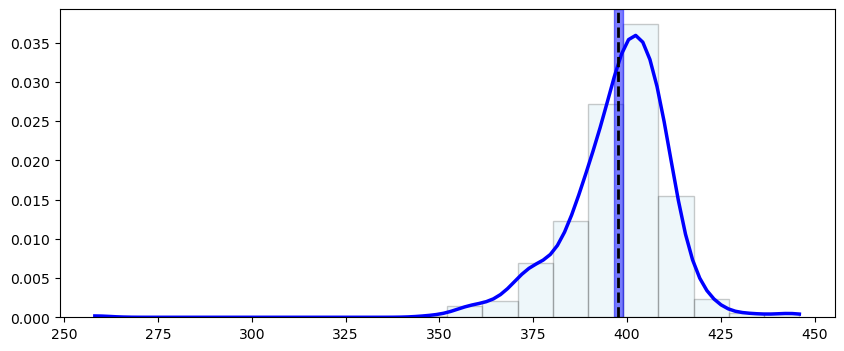

In [14]:
plt.figure(figsize=(10, 4))
plt.hist(wn_aver_speeds, bins=20, density=True, alpha=0.2, color='lightblue', edgecolor='black', label='WN')
x_wn = np.linspace(wn_aver_speeds.min(), wn_aver_speeds.max(), 100)
plt.plot(x_wn, stats.gaussian_kde(wn_aver_speeds)(x_wn), 'b-', linewidth=2.5, label='WN')
wn_mean = wn_aver_speeds.mean()
wn_sem = stats.sem(wn_aver_speeds)
wn_ci = stats.t.interval(0.95, len(wn_aver_speeds)-1, loc=wn_mean, scale=wn_sem)
plt.axvline(wn_mean, color='black', linestyle='--', linewidth=2)
plt.axvspan(wn_ci[0], wn_ci[1], alpha=0.5, color='blue')

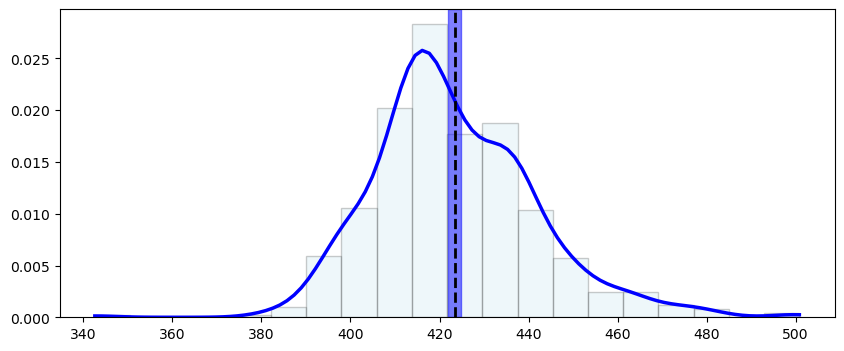

In [54]:
plt.figure(figsize=(10, 4))
plt.hist(ua_aver_speeds, bins=20, density=True, alpha=0.2, color='lightblue', edgecolor='black', label='UA')
x_ua = np.linspace(ua_aver_speeds.min(), ua_aver_speeds.max(), 100)
plt.plot(x_ua, stats.gaussian_kde(ua_aver_speeds)(x_ua), 'b-', linewidth=2.5, label='UA')
ua_mean = ua_aver_speeds.mean()
ua_sem = stats.sem(ua_aver_speeds)
ua_ci = stats.t.interval(0.95, len(ua_aver_speeds)-1, loc=ua_mean, scale=ua_sem)
plt.axvline(ua_mean, color='black', linestyle='--', linewidth=2)
plt.axvspan(ua_ci[0], ua_ci[1], alpha=0.5, color='blue')

**Графики:**  
Показаны распределения скоростей с доверительными интервалами (синяя область) и средние (пунктир). Визуально подтверждается различие.
*Доверительный интервал в синей области, среднее значение пунктирной линией*

## Задача 4. Зависимость расстояния от скорости полета
**Исследуем:**  
Связана ли средняя скорость самолета со средней дистанцией перелета?  
**Метод:**  
Линейная регрессия скорости на дистанцию

In [57]:
mean_dist = round(df_clean.groupby('tailnum')['distance'].mean(),4)
#При необxодимости повторяем фрагмент кода 3 задачи чуть его изменив
#df_clean['speed'] = (df_clean['distance']/df_clean['air_time'])*60
mean_speeds = round(df_clean.groupby('tailnum')['speed'].mean(),4)

In [58]:
x = mean_speeds.values.reshape(-1, 1)
y = mean_dist.values
lr = LinearRegression()
x_sorted = np.sort(x, axis=0)

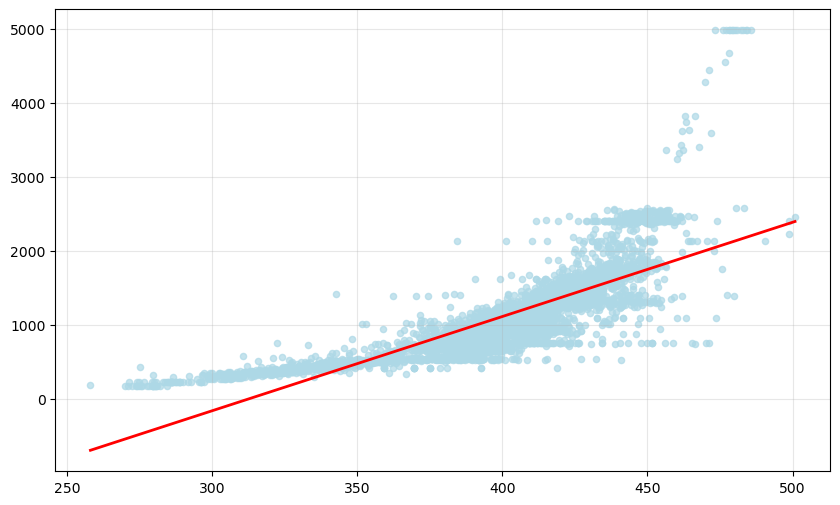

In [59]:
plt.figure(figsize=(10, 6))
plt.scatter(mean_speeds, mean_dist, alpha=0.7, s=20, color='lightblue')
plt.grid(True, alpha=0.3)
lr.fit(x, y)
y_pred = lr.predict(x_sorted)
plt.plot(x_sorted, y_pred, 'r-', linewidth=2)

**Результат регрессии:**  
Красная линия — линейная аппроксимация. Коэффициент наклона положительный, но разброс велик.  
**Вывод:**  
Связь есть, но слабая: более быстрые самолеты в среднем летают дальше, однако скорость не является хорошим предиктором расстояния. Есть большой разброс точек на графике, а также многие самолеты совершают короткие рейсы.

## Задача 5. Кластеризация самолетов по активности и скорости
**Исследуем:**  
Можно ли выделить типичные группы самолетов по числу выполненных рейсов и средней скорости.  
**Метод:**  
Алгоритм K-means. Выбрано k=7.

*стандартизируем имеющиеся значения*

In [61]:
flights_count = df_clean.groupby('tailnum')['flight'].count()
planes_speed = df_clean.groupby('tailnum')['speed'].mean()
planes = pd.DataFrame({
    'number': flights_count,
    'avspeed': planes_speed
})

*разбиваем значения на кластеры*

In [78]:
ss = StandardScaler()
x_scaled = ss.fit_transform(planes[['avspeed', 'number']])
k = 7
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
planes['cluster'] = kmeans.fit_predict(x_scaled)
centers_original = ss.inverse_transform(kmeans.cluster_centers_)
for i in range(k):
    size = len(planes[planes['cluster'] == i])
    print(f"Кластер {i}: {size} самолетов ({size/len(planes)*100:.1f}%)")

Кластер 0: 566 самолетов (14.0%)
Кластер 1: 327 самолетов (8.1%)
Кластер 2: 206 самолетов (5.1%)
Кластер 3: 1334 самолетов (33.0%)
Кластер 4: 413 самолетов (10.2%)
Кластер 5: 279 самолетов (6.9%)
Кластер 6: 912 самолетов (22.6%)


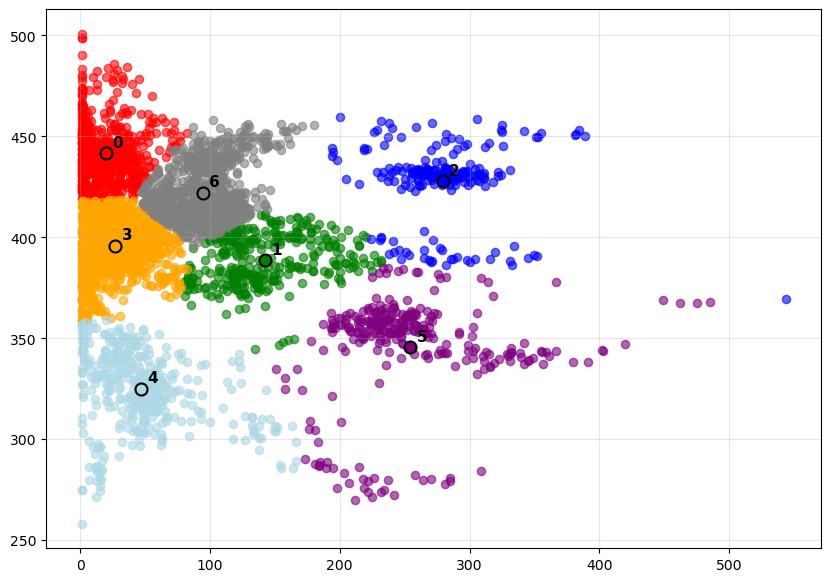

In [79]:
#(с кластеризацией помогал ИИ, я до этого не занимался ей)
colors = ['red', 'green', 'blue', 'orange','lightblue','purple','grey']
plt.figure(figsize=(10, 7))

for i in range(k):
    cluster_data = planes[planes['cluster'] == i]
    plt.scatter(cluster_data['number'], cluster_data['avspeed'], 
                alpha=0.6, s=35, color=colors[i], 
                label=f'Кластер {i} (n={len(cluster_data)})')

for i in range(k):
    plt.scatter(centers_original[i, 1], centers_original[i, 0], 
                color=colors[i], marker='.', s=300, 
                edgecolor='black', linewidth=1.5, zorder=1)
for i in range(k):
    plt.text(centers_original[i, 1] + 5, centers_original[i, 0] + 3, 
             f'{i}', fontsize=11, color='black', fontweight='bold')
plt.grid(True, alpha=0.3)

**Оси**
По оси Y - средняя скорость, по оси X - количество рейсов
**Результаты кластеризации:**  
Кластеризация выделила 7 групп:
1. Кластер 0 - это высокоскоростные борта с малым числом рейсов (предполагаю, что частные самолеты)
2. Кластер 1 - средняя скорость, средняя популярность
3. Кластер 2 - популярные перелеты на средней и выской скоростях (популярные рейсы на небольшие расстояния)
4. Кластер 3 - средняя скорость, мало рейсов - непопулярные дальние перелеты, количество которых преобладает
5. Кластер 4 - низкоскоростные и непопулярные (возможно, устаревшие) самолеты
6. Кластер 5 - наиболее активный парк, выполняет очень много рейсов со средней скоростью, бюджетные перевозки.
7. Кластер 6 - скоростные рейсы, большое количество самолетов (отдельные рейсы непопулярны, но маршрутов достаточно много)

**Вывод:**  
Кластеризация позволяет выделить эксплуатационные группы самолетов, что полезно для оптимизации парка.